In [1]:
import sys
from pathlib import Path
sys.path.append("/export/home/mklockow/boa")

import os
os.environ["PROJECT_ROOT"] = "/export/home/mklockow/boa"

import hydra
from hydra import initialize, compose
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import torch

from dotenv import load_dotenv
load_dotenv()

# Monkey patch the HydraConfig.get method to avoid the error
from hydra.core.hydra_config import HydraConfig

# Store the original method before patching
_original_get = HydraConfig.get

@classmethod 
def patched_get(cls):
    try:
        instance = cls.instance()
        if instance.cfg is None:
            raise ValueError("HydraConfig was not set")
        return instance.cfg.hydra
    except ValueError:
        # Return a minimal mock config when HydraConfig is not set
        from omegaconf import DictConfig
        mock_config = DictConfig({
            "job": {
                "override_dirname": "",
                "num": "0"
            },
            "runtime": {
                "output_dir": "/tmp/hydra_fallback"
            },
            "sweep": {
                "dir": "/tmp/hydra_sweep"
            }
        })
        return mock_config

# Apply the monkey patch
HydraConfig.get = patched_get

# Import and register the custom resolvers from your project
from boa.utils.omegaconf_resolvers import *

from boa.model.module import ChgLightningModule

run_path = Path("/export/scratch/mklockow/boa/models/train/runs/437_qm9_small_qm9_vasp_small__seed-2")
best_ckpt = (run_path / "best_model_path.txt").read_text().strip()
model_path = run_path / best_ckpt
config_path = run_path / "config.yaml"

# cfg = OmegaConf.load(config_path)

with initialize(config_path="../configs", version_base="1.1"):
    cfg = compose(config_name="train.yaml", overrides=["data=md", "data.datamodule.dataset.mol_name=benzene", "data.datamodule.dataset.n_probe=null", "data.basis_info.basis=def2-svp"]) # def2-svp

# First instantiate datamodule to get metadata
datamodule = hydra.utils.instantiate(cfg.data.datamodule, _recursive_=False)
datamodule.setup("fit")  # This creates the metadata
metadata = datamodule.metadata

print(f"Metadata: {metadata}")

# Now instantiate model with proper metadata
model = hydra.utils.instantiate(cfg.model, train=cfg, _recursive_=False, metadata=metadata)
# model = ChgLightningModule.load_from_checkpoint(model_path, map_location="cpu")

Precomputing train density from FFT coefficients ...
Precomputing test density from FFT coefficients ...
Metadata: {'target_mean': 0.04942677915096283, 'target_var': 0.09023565798997879, 'avg_num_neighbors': 3, 'unique_atom_types': [1, 6]}
Unique atom types: [1 6]
Using radial correction for GTOs.
Using radial correction for GTOs.
self.linear_basis: False


In [2]:
val_set = datamodule.val_dataset
sample = val_set[0]
print(sample)

OFData(
  pos=[12, 3],
  atomic_numbers=[12],
  coeffs=[186],
  atom_ind=[12],
  n_basis_per_atom=[12],
  atom_ptr=[12],
  basis_function_ind=[186],
  coeff_ind_to_node_ind=[186],
  dual_basis_integrals=[186],
  irreps_per_atom=[12],
  representations={
    pos=Representation.NONE,
    atomic_numbers=Representation.NONE,
    coeffs=Representation.VECTOR,
    ground_state_coeffs=Representation.VECTOR,
    gradient_label=Representation.GRADIENT,
    energy_label=Representation.SCALAR,
    has_energy_label=Representation.NONE,
    atom_ind=Representation.NONE,
    n_basis_per_atom=Representation.NONE,
    atom_ptr=Representation.NONE,
    basis_function_ind=Representation.NONE,
    coeff_ind_to_node_ind=Representation.NONE,
    dual_basis_integrals=Representation.DUAL_VECTOR,
    mol_id=Representation.NONE,
    scf_iteration=Representation.NONE,
    irreps_per_atom=Representation.NONE,
    representations=Representation.NONE,
    n_probe=Representation.NONE,
    cell=Representation.VECTOR

In [3]:
import pyvista as pv

2026-04-16 09:46:27.983 (  13.363s) [    7D37B38A4740]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


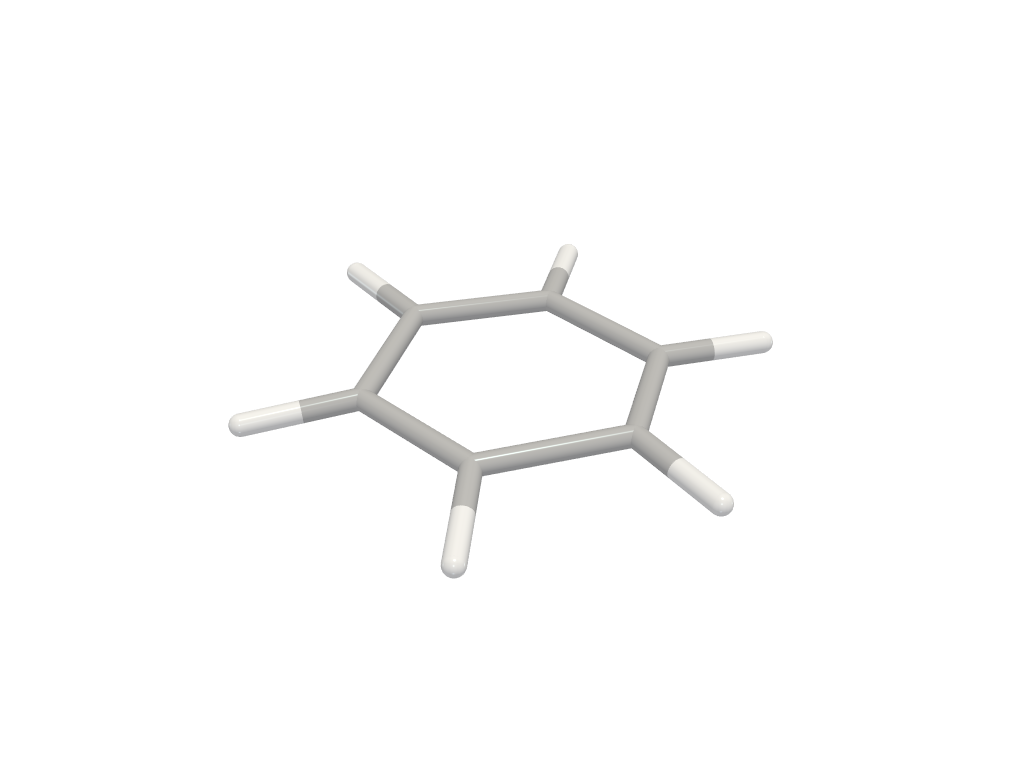

In [4]:
import pyvista as pv
from mldft.utils.visualize_3d import get_sticks_mesh_dict
from mldft.utils.molecules import build_molecule_ofdata

# Switch to static backend for better sphere rendering in notebooks
# pv.set_jupyter_backend('static')  # Use static backend for notebooks
# pv.set_jupyter_backend('html')    # Interactive with panel
# pv.set_jupyter_backend('trame')    # Interactive with trame
# pv.set_jupyter_backend('pythreejs') # Interactive with pythreejs

mol = build_molecule_ofdata(sample)
pv.set_jupyter_backend('static')
pl = pv.Plotter(notebook=True)
pl.add_mesh(**get_sticks_mesh_dict(mol))
pl.show()

In [5]:
model.gto_dict

ModuleDict(
  (1): GTOs(Lmax=1, n_orbitals=5, n_contracted=5.0, outdim=7)
  (6): GTOs(Lmax=2, n_orbitals=12, n_contracted=12.0, outdim=24)
)

In [6]:
import numpy as np
from scipy.spatial.distance import cdist

def compute_gaussian_product_peaks(sample, gto_dict, min_distance_threshold=0.1):
    """
    Compute the peaks of Gaussian products for neighboring atoms within cutoff.
    
    When two Gaussians exp(-α₁|r-R₁|²) and exp(-α₂|r-R₂|²) are multiplied,
    the product is a Gaussian with peak at: R_peak = (α₁R₁ + α₂R₂)/(α₁ + α₂)
    
    Args:
        sample: Molecule data containing positions, atomic numbers, edge_index
        gto_dict: Dictionary of GTOs for each atom type
        min_distance_threshold: Minimum distance between peaks to avoid duplicates
    
    Returns:
        peak_coords: Tensor of shape (N_peaks, 3) with peak coordinates
        peak_info: List of dictionaries with metadata for each peak
    """
    
    # Get molecular information
    atomic_numbers = sample.atomic_numbers
    positions = sample.pos
    edge_index = sample.edge_index
    
    # Store all peaks and their metadata
    all_peaks = []
    peak_info = []
    
    # Process each edge (atom pair)
    for edge_idx in range(edge_index.shape[1]):
        atom_i_idx = edge_index[0, edge_idx].item()
        atom_j_idx = edge_index[1, edge_idx].item()
        
        # Skip self-loops for now (we could include them for completeness)
        if atom_i_idx == atom_j_idx:
            continue
            
        atom_i_type = atomic_numbers[atom_i_idx].item()
        atom_j_type = atomic_numbers[atom_j_idx].item()
        
        pos_i = positions[atom_i_idx]
        pos_j = positions[atom_j_idx]
        
        # Check if atoms are within cutoff distance
        distance = torch.norm(pos_i - pos_j).item()
        
        # Get GTOs for both atoms
        gto_i = gto_dict[str(atom_i_type)]
        gto_j = gto_dict[str(atom_j_type)]
        
        if distance > max(gto_i.cutoff, gto_j.cutoff):
            continue
            
        # Get exponents for both atoms
        expos_i = gto_i.expos
        expos_j = gto_j.expos
        
        # Compute peaks for all combinations of basis functions
        for k, exp_i in enumerate(expos_i):
            for l, exp_j in enumerate(expos_j):
                # Peak of product of two Gaussians: weighted average of centers
                alpha_i = exp_i.item()
                alpha_j = exp_j.item()
                
                # Peak position: (α₁R₁ + α₂R₂)/(α₁ + α₂)
                peak_pos = (alpha_i * pos_i + alpha_j * pos_j) / (alpha_i + alpha_j)
                
                # Store peak information
                peak_info_dict = {
                    'atom_i_idx': atom_i_idx,
                    'atom_j_idx': atom_j_idx,
                    'atom_i_type': atom_i_type,
                    'atom_j_type': atom_j_type,
                    'atom_i_pos': pos_i.clone(),
                    'atom_j_pos': pos_j.clone(),
                    'basis_i_idx': k,
                    'basis_j_idx': l,
                    'exp_i': alpha_i,
                    'exp_j': alpha_j,
                    'distance': distance,
                    'peak_pos': peak_pos.clone()
                }
                
                all_peaks.append(peak_pos)
                peak_info.append(peak_info_dict)
    
    if not all_peaks:
        return torch.empty(0, 3), []
    
    # Convert to tensor
    peak_coords = torch.stack(all_peaks)
    
    # Remove duplicates that are too close together
    if min_distance_threshold > 0:
        unique_peaks = []
        unique_info = []
        
        for i, (peak, info) in enumerate(zip(peak_coords, peak_info)):
            is_duplicate = False
            for existing_peak in unique_peaks:
                if torch.norm(peak - existing_peak) < min_distance_threshold:
                    is_duplicate = True
                    break
            
            if not is_duplicate:
                unique_peaks.append(peak)
                unique_info.append(info)
        
        if unique_peaks:
            peak_coords = torch.stack(unique_peaks)
            peak_info = unique_info
        else:
            peak_coords = torch.empty(0, 3)
            peak_info = []
    
    return peak_coords, peak_info

# Test the function
peaks, peak_info = compute_gaussian_product_peaks(sample, model.gto_dict, min_distance_threshold=0)
print(f"Found {len(peaks)} unique Gaussian product peaks")
print(f"Peak coordinates shape: {peaks.shape}")

Found 6780 unique Gaussian product peaks
Peak coordinates shape: torch.Size([6780, 3])


In [7]:
def get_atoms_only_mesh_dict(sample, atom_radius=0.2, resolution=20):
    """
    Create an atoms-only representation for a molecule (no bonds).
    
    Args:
        sample: Molecule data containing positions and atomic numbers
        atom_radius: The radius of the spheres representing atoms
        resolution: The resolution of the spheres
        
    Returns:
        A dictionary with keyword arguments to pass to pyvista.Plotter.add_mesh
    """
    # Color mapping for atoms
    ATOM_COLORS = {
        1: "#eeeeee",   # H - white
        6: "#555555",   # C - gray
        7: "#8f8fff",   # N - blue
        8: "#f00000",   # O - red
        9: "#ffff00",   # F - yellow
        15: "#ffa500",  # P - orange
        16: "#ffc832",  # S - yellow
        19: "#42f4ee",  # K - cyan
        0: "#3f3f3f",   # Unknown - dark gray
    }
    
    # Get positions and atomic numbers directly from sample
    positions = sample.pos  # Already in Bohr
    atomic_numbers = sample.atomic_numbers
    
    mesh_elements = []
    
    # Create spheres for atoms only
    for i, (pos, atomic_num) in enumerate(zip(positions, atomic_numbers)):
        atomic_num = atomic_num.item()
        color_id = list(ATOM_COLORS.keys()).index(atomic_num) if atomic_num in ATOM_COLORS else list(ATOM_COLORS.keys()).index(0)
        
        sphere = pv.Sphere(
            center=pos.numpy(),
            radius=atom_radius,
            phi_resolution=resolution,
            theta_resolution=resolution,
        )
        sphere["color_ids"] = np.ones(sphere.n_cells) * color_id
        mesh_elements.append(sphere)
    
    merged_mesh = pv.MultiBlock(mesh_elements).combine().extract_surface()
    add_mesh_kwargs = dict(
        mesh=merged_mesh,
        smooth_shading=True,
        diffuse=0.5,
        specular=0.5,
        ambient=0.5,
        clim=(0, len(ATOM_COLORS)-1),
        cmap=list(ATOM_COLORS.values()),
        show_scalar_bar=False,
    )
    return add_mesh_kwargs

def find_isosurface_value(
    cube_array: np.ndarray, quantile: float | np.ndarray = 0.9, p: int = 2
) -> float | np.ndarray:
    """Find an isosurface value for a cube array, such that the isosurface contains a given
    fraction of the total mass. The mass is computed as the sum of the absolute values of the cube
    array raised to the power p.

    Args:
        cube_array: The cube array.
        quantile: The fraction (or array of fractions) of the total mass to be contained in the isosurface.
        p: The power to raise the cube array to. Use p=1 for electron density and p=2 for orbitals.

    Returns:
        The isosurface value.
    """
    cube_array = np.abs(cube_array).flatten()
    mass = cube_array**p
    total_mass = mass.sum()
    mass_sorted = np.sort(mass)[::-1]
    ind = np.searchsorted(np.cumsum(mass_sorted), total_mass * quantile)
    isosurface_value = mass_sorted[ind] ** (1 / p)

    return isosurface_value

In [8]:
# Find indices of H-H (hydrogen-hydrogen) connections
hh_indices = []
for i, info in enumerate(peak_info):
    atom_i_type = info['atom_i_type']
    atom_j_type = info['atom_j_type']
    
    # Check if both atoms are hydrogen (atomic number 1)
    if atom_i_type == 1 and atom_j_type == 1:
        hh_indices.append(i)

print(f"Found {len(hh_indices)} H-H connections out of {len(peak_info)} total peaks")
print(f"H-H connection indices: {hh_indices[:20]}...")  # Show first 20
print(f"Percentage of H-H connections: {len(hh_indices)/len(peak_info)*100:.1f}%")

# Also find other connection types for comparison
cc_indices = []  # Carbon-Carbon
ch_indices = []  # Carbon-Hydrogen

for i, info in enumerate(peak_info):
    atom_i_type = info['atom_i_type']
    atom_j_type = info['atom_j_type']
    
    # Carbon-Carbon connections
    if atom_i_type == 6 and atom_j_type == 6:
        cc_indices.append(i)
    
    # Carbon-Hydrogen connections (either C-H or H-C)
    if (atom_i_type == 6 and atom_j_type == 1) or (atom_i_type == 1 and atom_j_type == 6):
        ch_indices.append(i)

Found 300 H-H connections out of 6780 total peaks
H-H connection indices: [5400, 5401, 5402, 5403, 5404, 5405, 5406, 5407, 5408, 5409, 5410, 5411, 5412, 5413, 5414, 5415, 5416, 5417, 5418, 5419]...
Percentage of H-H connections: 4.4%


In [9]:
def print_peak_info(selected_peak_info):
    print(f"Selected peak between atoms {selected_peak_info['atom_i_idx']} and {selected_peak_info['atom_j_idx']}")
    print(f"Atom types: {selected_peak_info['atom_i_type']} and {selected_peak_info['atom_j_type']}")
    print(f"Basis functions: {selected_peak_info['basis_i_idx']} and {selected_peak_info['basis_j_idx']}")
    print(f"Peak position: {selected_peak_info['peak_pos']}")

    # Get GTO info for the specific basis functions
    gto_i = model.gto_dict[str(selected_peak_info['atom_i_type'])]
    gto_j = model.gto_dict[str(selected_peak_info['atom_j_type'])]
    L_i = gto_i.Ls[selected_peak_info['basis_i_idx']].item()
    L_j = gto_j.Ls[selected_peak_info['basis_j_idx']].item()
    print(f"Angular momentum: L_i = {L_i}, L_j = {L_j}")
    print(f"Number of spherical harmonics: (2*{L_i}+1) = {2*L_i+1}, (2*{L_j}+1) = {2*L_j+1}")

In [10]:
selected_peak_info = peak_info[5400]  # Pick first peak
selected_peak_pos = selected_peak_info['peak_pos']
print_peak_info(selected_peak_info)

def plot_mol_and_connections(plotter):
    plotter.enable_shadows()
    plotter.enable_anti_aliasing()
    
    # Add atoms with slight transparency to allow volume rendering through them
    atom_mesh_kwargs = get_atoms_only_mesh_dict(sample, atom_radius=0.2, resolution=40)
    plotter.add_mesh(**atom_mesh_kwargs)  # Slight transparency
    
    # Add peak points
    # point_size=40
    plotter.add_points(peaks.numpy(), color='#60bc9cff', point_size=80, render_points_as_spheres=True, metallic=0., roughness=0.4, opacity=0.999)
    plotter.add_points(selected_peak_info['peak_pos'].numpy().reshape(1, -1), color='#f39c12', point_size=80, render_points_as_spheres=True, metallic=0., roughness=0.2, opacity=1)
    return plotter

Selected peak between atoms 7 and 6
Atom types: 1 and 1
Basis functions: 0 and 0
Peak position: tensor([4.3045, 7.1751, 5.2822])
Angular momentum: L_i = 0, L_j = 0
Number of spherical harmonics: (2*0+1) = 1, (2*0+1) = 1


In [11]:
def compute_gaussian_product_3d(peak_info_single, gto_dict, grid_resolution=60, extent=1.5, m1=0, m2=0):
    """
    Compute the 3D Gaussian product function on a grid around the peak using full GTOs.
    
    Args:
        peak_info_single: Single peak info dictionary
        gto_dict: Dictionary of GTOs for each atom type
        grid_resolution: Number of grid points in each dimension (increased for smoother rendering)
        extent: Half-size of the grid in Bohr
        use_all_orbitals: If True, sum over all orbitals for each radial function.
                         If False, use the maximum component (for visualization)
        
    Returns:
        grid: PyVista structured grid with Gaussian product values
    """
    # Extract information
    pos_i = peak_info_single['atom_i_pos']
    pos_j = peak_info_single['atom_j_pos']
    atom_i_type = peak_info_single['atom_i_type']
    atom_j_type = peak_info_single['atom_j_type']
    basis_i_idx = peak_info_single['basis_i_idx']
    basis_j_idx = peak_info_single['basis_j_idx']
    peak_pos = peak_info_single['peak_pos']
    
    # Get the GTO objects for both atoms
    gto_i = gto_dict[str(atom_i_type)]
    gto_j = gto_dict[str(atom_j_type)]
    
    # Create 3D grid centered around the peak
    x = torch.linspace(peak_pos[0] - extent, peak_pos[0] + extent, grid_resolution)
    y = torch.linspace(peak_pos[1] - extent, peak_pos[1] + extent, grid_resolution)
    z = torch.linspace(peak_pos[2] - extent, peak_pos[2] + extent, grid_resolution)
    
    # Create meshgrid
    X, Y, Z = torch.meshgrid(x, y, z, indexing='ij')
    grid_points = torch.stack([X.flatten(), Y.flatten(), Z.flatten()], dim=1)
    
    # Compute displacement vectors from each atom to all grid points
    vecs_i = grid_points - pos_i.unsqueeze(0)  # (N_grid, 3)
    vecs_j = grid_points - pos_j.unsqueeze(0)  # (N_grid, 3)
    
    # Convert to Angstrom for GTO computation (GTOs expect Angstrom input)
    from scdp.common.constants import bohr2ang
    vecs_i_ang = vecs_i / bohr2ang
    vecs_j_ang = vecs_j / bohr2ang
    
    # Compute GTOs at all grid points
    with torch.no_grad():  # Disable gradient computation to avoid issues
        gto_values_i = gto_i.compute(vecs_i_ang)  # (N_grid, n_orbitals_i)
        gto_values_j = gto_j.compute(vecs_j_ang)  # (N_grid, n_orbitals_j)
    
    # Extract the specific basis function values
    # Find which columns correspond to our basis functions
    # Each radial function contributes (2*L+1) spherical harmonics
    start_idx_i = 0
    for l_idx in range(basis_i_idx):
        start_idx_i += 2 * gto_i.Ls[l_idx] + 1
    idx_i = start_idx_i + m1
    
    start_idx_j = 0
    for l_idx in range(basis_j_idx):
        start_idx_j += 2 * gto_j.Ls[l_idx] + 1
    idx_j = start_idx_j + m2  # Fixed: was start_idx_i + m2
    print(f"Selected GTOs: {idx_i}, {idx_j}")
    # Get orbital components for the specific radial functions
    gto_i_selected = gto_values_i[:, idx_i]  # (N_grid, 2*L_i+1)
    gto_j_selected = gto_values_j[:, idx_j]  # (N_grid, 2*L_j+1)

    # Compute the product
    product = gto_i_selected * gto_j_selected
    
    # Reshape back to 3D
    product_3d = product.reshape(grid_resolution, grid_resolution, grid_resolution)
    
    # Create PyVista structured grid
    grid = pv.StructuredGrid(X.numpy(), Y.numpy(), Z.numpy())
    grid["gaussian_product"] = product_3d.detach().numpy().flatten()
    
    return grid

# Use higher resolution for smoother rendering
gaussian_grid = compute_gaussian_product_3d(selected_peak_info, model.gto_dict, grid_resolution=80, extent=3.0, m1=2, m2=2)
gaussian_values = gaussian_grid["gaussian_product"]
print(gaussian_values.min(), gaussian_values.max(), gaussian_values.mean())

Selected GTOs: 2, 2
6.74979e-40 0.012177056 5.2468164e-05


In [12]:
# Debug: Let's check the GTO values and distances
print(f"Peak info: atoms {selected_peak_info['atom_i_idx']}-{selected_peak_info['atom_j_idx']}, types {selected_peak_info['atom_i_type']}-{selected_peak_info['atom_j_type']}")
print(f"Atom positions: {selected_peak_info['atom_i_pos']} and {selected_peak_info['atom_j_pos']}")
print(f"Distance between atoms: {selected_peak_info['distance']:.4f} Bohr")
print(f"Peak position: {selected_peak_info['peak_pos']}")

# Check the GTO shapes and values at the peak
gto_i = model.gto_dict[str(selected_peak_info['atom_i_type'])]
gto_j = model.gto_dict[str(selected_peak_info['atom_j_type'])]
print(f"GTO_i exponents: {gto_i.expos}")
print(f"GTO_j exponents: {gto_j.expos}")
print(f"GTO_i Ls: {gto_i.Ls}")
print(f"GTO_j Ls: {gto_j.Ls}")

# Test GTO computation at the peak position
from scdp.common.constants import bohr2ang
peak_pos = selected_peak_info['peak_pos']
vec_i_peak = (peak_pos - selected_peak_info['atom_i_pos']).unsqueeze(0) / bohr2ang
vec_j_peak = (peak_pos - selected_peak_info['atom_j_pos']).unsqueeze(0) / bohr2ang

with torch.no_grad():
    gto_i_at_peak = gto_i.compute(vec_i_peak)
    gto_j_at_peak = gto_j.compute(vec_j_peak)
    
print(f"GTO_i at peak: {gto_i_at_peak}")
print(f"GTO_j at peak: {gto_j_at_peak}")
print(f"Product at peak: {gto_i_at_peak * gto_j_at_peak}")

Peak info: atoms 7-6, types 1-1
Atom positions: tensor([3.2202, 6.5678, 5.2847]) and tensor([5.3887, 7.7824, 5.2798])
Distance between atoms: 2.4855 Bohr
Peak position: tensor([4.3045, 7.1751, 5.2822])
GTO_i exponents: tensor([13.0107,  1.9623,  0.4445,  0.1219,  0.8000])
GTO_j exponents: tensor([13.0107,  1.9623,  0.4445,  0.1219,  0.8000])
GTO_i Ls: tensor([0, 0, 0, 0, 1])
GTO_j Ls: tensor([0, 0, 0, 0, 1])
GTO_i at peak: tensor([[ 1.0296e-30,  7.9137e-05,  1.0927e-01,  2.3657e-01,  5.1926e-02,
          2.9083e-02, -1.1726e-04]])
GTO_j at peak: tensor([[ 1.0296e-30,  7.9137e-05,  1.0927e-01,  2.3657e-01, -5.1925e-02,
         -2.9083e-02,  1.1729e-04]])
Product at peak: tensor([[ 0.0000e+00,  6.2626e-09,  1.1940e-02,  5.5968e-02, -2.6963e-03,
         -8.4583e-04, -1.3754e-08]])


In [13]:
# Let's try a different combination - use indices 2,2 which showed good values above
gaussian_grid_test = compute_gaussian_product_3d(selected_peak_info, model.gto_dict, grid_resolution=50, extent=3.0, m1=2, m2=2)
gaussian_values_test = gaussian_grid_test["gaussian_product"]
print("With m1=2, m2=2:")
print(gaussian_values_test.min(), gaussian_values_test.max(), gaussian_values_test.mean())

Selected GTOs: 2, 2
With m1=2, m2=2:
6.74979e-40 0.011928488 5.126758e-05


In [16]:
pv.set_jupyter_backend('static')
window_size = (4000, 4000)
plotter = pv.Plotter(notebook=True, window_size=window_size)
plotter.enable_anti_aliasing('msaa')
plotter.enable_depth_peeling(15)

plotter = plot_mol_and_connections(plotter)

rgba = np.zeros((gaussian_grid.n_points, 4), np.uint8)
neg_mask = gaussian_values < 0
max_opacity = 2

if neg_mask.sum() == 0:
    rgba[:, 2] = 170
    rgba[:, -1] = ((gaussian_values / gaussian_values.max()) **1.5 * max_opacity)
else:
    rgba[neg_mask, 0] = 170
    rgba[~neg_mask, 2] = 170
    opac = np.abs(gaussian_values)  # ** 2
    opac /= find_isosurface_value(opac, 0.25, p=1)
    opac = np.clip(opac, 0, 1)
    rgba[:, -1] = opac * max_opacity

gaussian_grid["plot_scalars"] = rgba

# Add volume with improved settings for smoother rendering
vol = plotter.add_volume(
    gaussian_grid,
    scalars="plot_scalars",
)

# Volume properties for minimal color bleeding
vol.prop.interpolation_type = "linear"
vol.prop.shade = False  # Disable shading to reduce color interactions
# vol.prop.ambient = 0.0  # Minimal ambient lighting
# vol.prop.diffuse = 0.0  # Reduced diffuse
# vol.prop.specular = 0.0  # No specular highlights

plotter.camera_position = 'iso'
plotter.camera.zoom(1.2)



# plotter.show()
# _ = plotter.screenshot('bonds_full_gtos_smooth.png', transparent_background=True, window_size=window_size)

Isosurface threshold: 0.005990
Positive surface cells: 1480
Negative surface cells: None


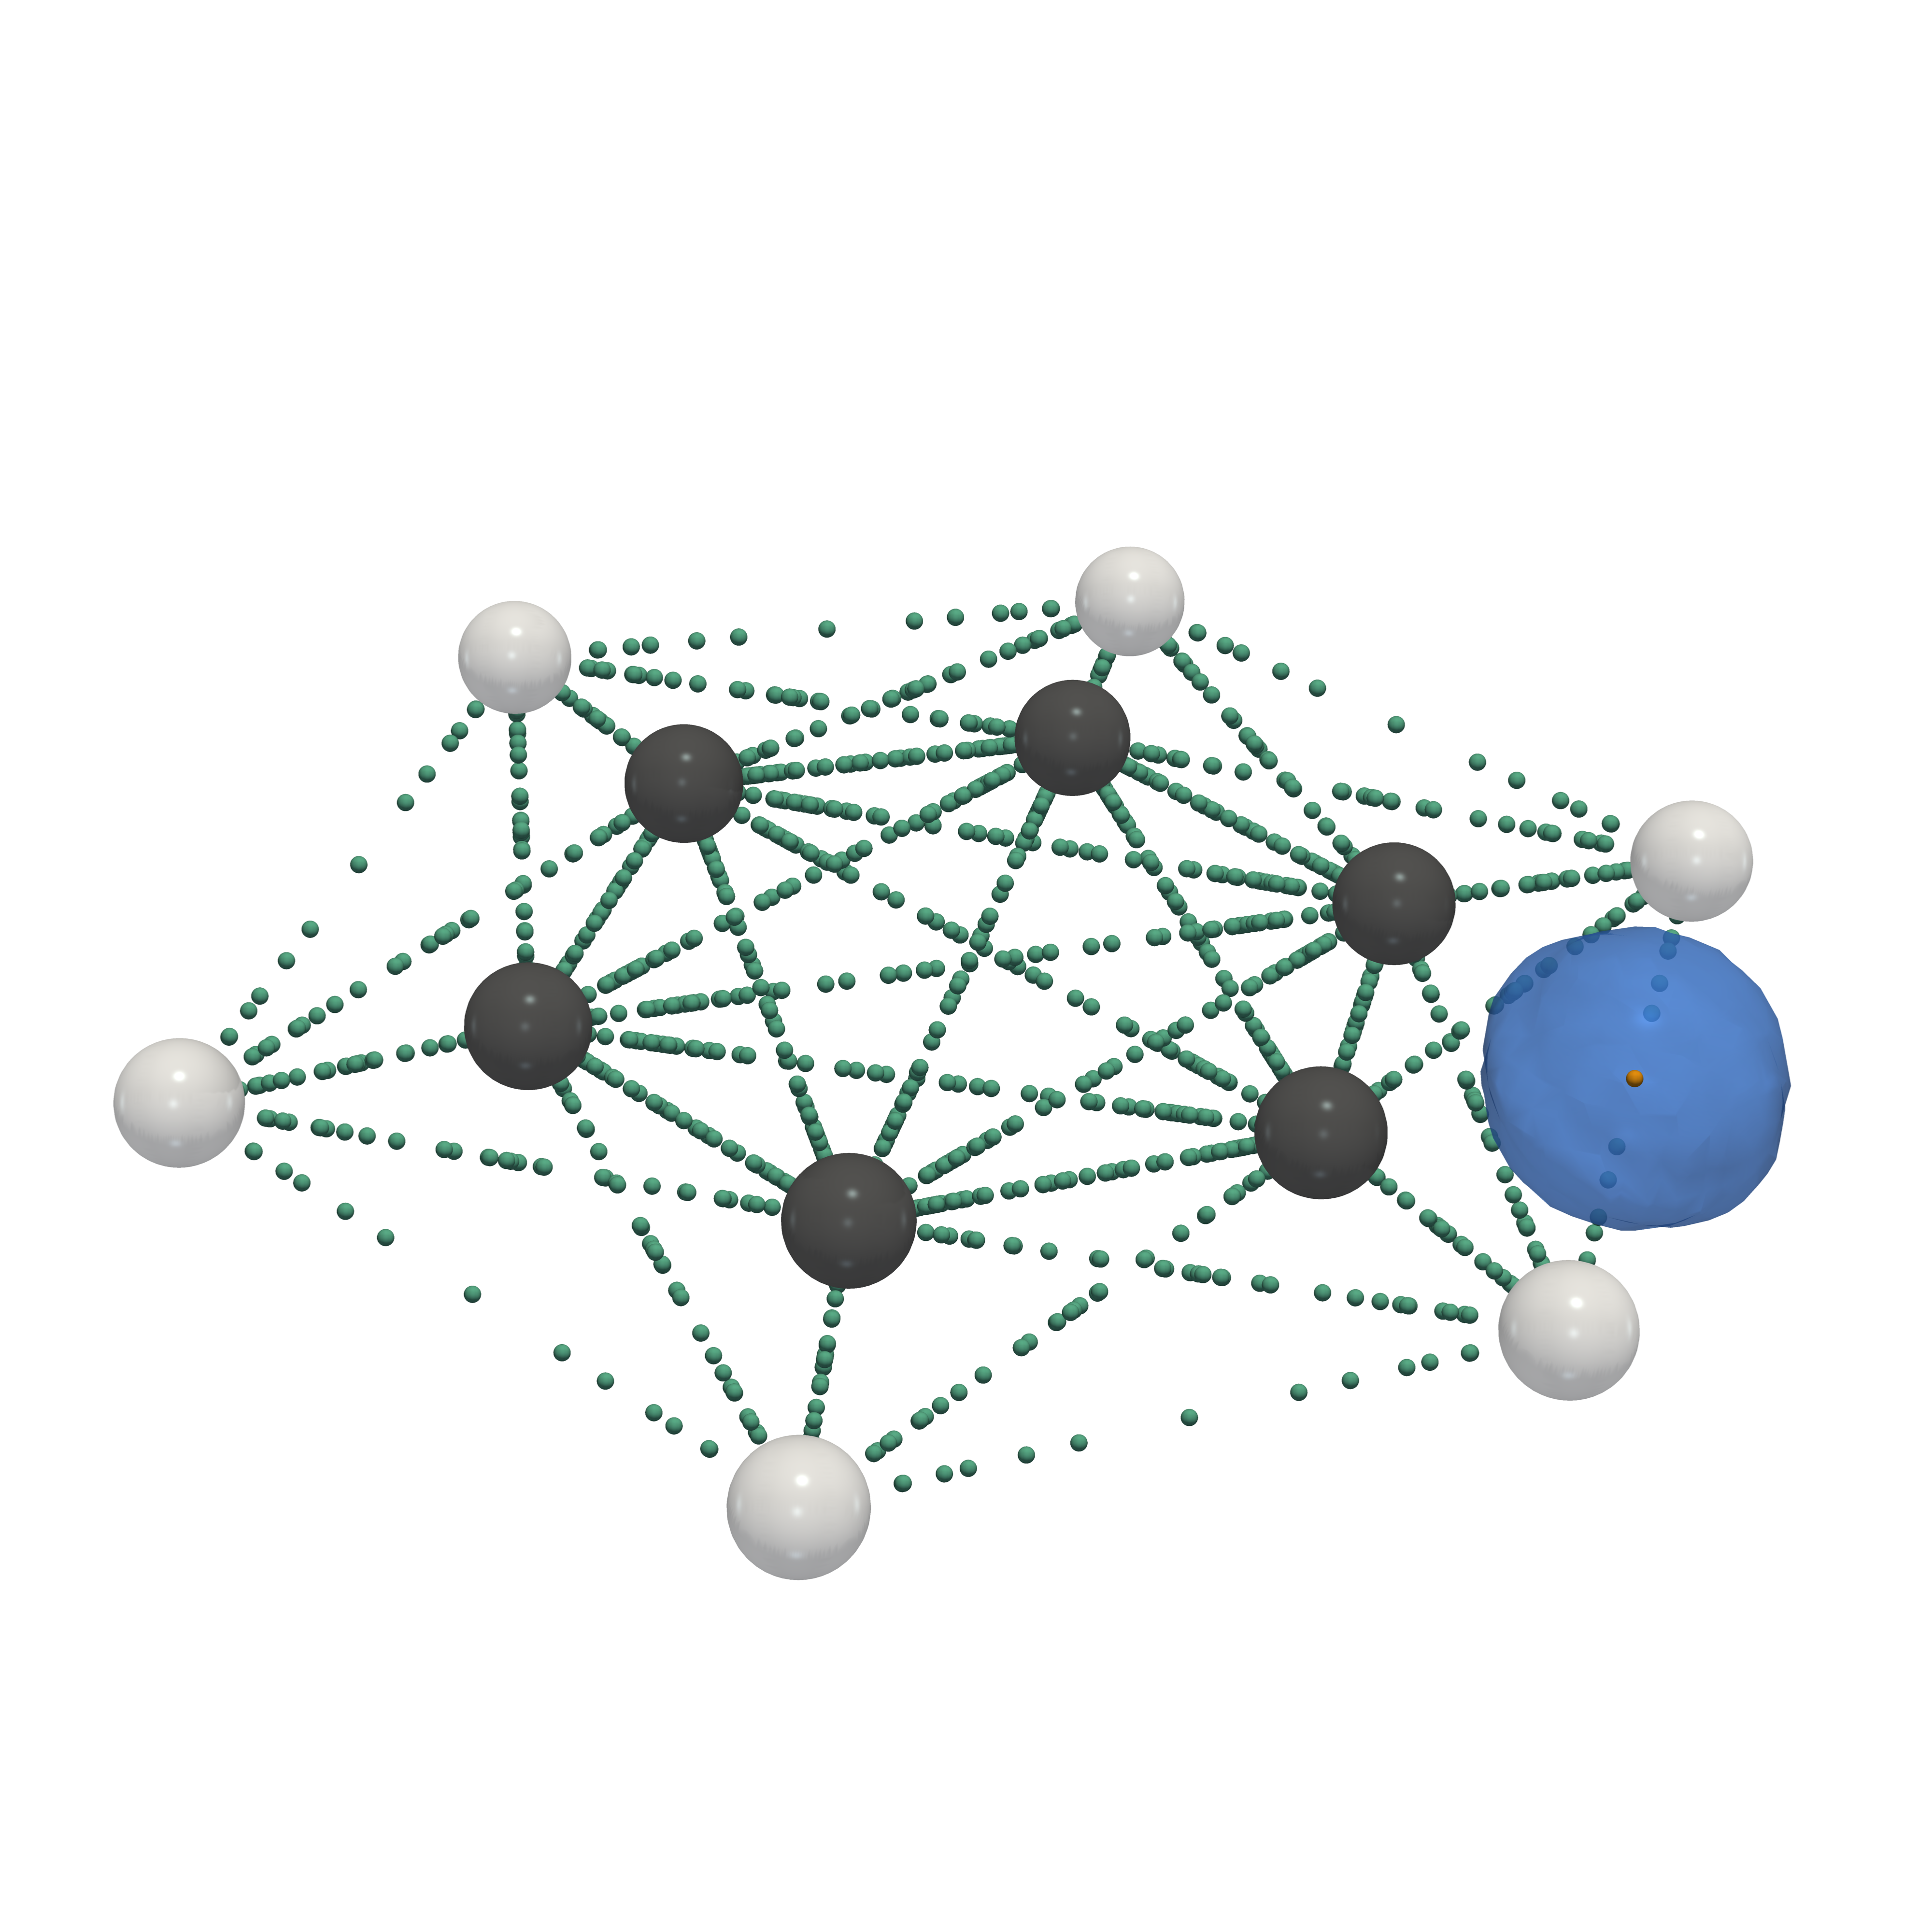

In [17]:
# Alternative: Create an isosurface for even smoother rendering
def create_smooth_isosurface(gaussian_grid, gaussian_values, isosurface_quantile=0.3):
    """
    Create a smooth isosurface instead of volume rendering for smoother appearance.
    """
    # Find appropriate isosurface value
    threshold = find_isosurface_value(np.abs(gaussian_values), isosurface_quantile, p=1)
    
    # Create isosurface for positive values
    pos_surface = gaussian_grid.contour([threshold], scalars="gaussian_product")
    
    # Create isosurface for negative values if they exist
    neg_mask = gaussian_values < 0
    if neg_mask.sum() > 0:
        neg_surface = gaussian_grid.contour([-threshold], scalars="gaussian_product")
        return pos_surface, neg_surface, threshold
    else:
        return pos_surface, None, threshold

# Create isosurface version
pos_surface, neg_surface, threshold = create_smooth_isosurface(gaussian_grid, gaussian_values, 0.3)

# Plot with isosurfaces for comparison
plotter_iso = pv.Plotter(notebook=True, window_size=window_size)
plotter_iso = plot_mol_and_connections(plotter_iso)

# Add positive isosurface (blue)
if pos_surface.n_cells > 0:
    plotter_iso.add_mesh(
        pos_surface, 
        color='#4287f5', 
        opacity=0.6, 
        smooth_shading=True,
        specular=0.3,
        ambient=0.2,
        diffuse=0.8
    )

# Add negative isosurface (red) if it exists
if neg_surface is not None and neg_surface.n_cells > 0:
    plotter_iso.add_mesh(
        neg_surface, 
        color='#f54242', 
        opacity=0.6, 
        smooth_shading=True,
        specular=0.3,
        ambient=0.2,
        diffuse=0.8
    )

plotter_iso.camera_position = 'iso'
plotter_iso.camera.zoom(1.2)
plotter_iso.enable_anti_aliasing('msaa')

print(f"Isosurface threshold: {threshold:.6f}")
print(f"Positive surface cells: {pos_surface.n_cells if pos_surface.n_cells > 0 else 'None'}")
print(f"Negative surface cells: {neg_surface.n_cells if neg_surface is not None and neg_surface.n_cells > 0 else 'None'}")

plotter_iso.show()
_ = plotter_iso.screenshot('bonds_isosurface_smooth.png', transparent_background=True, window_size=window_size)

In [ ]:
# import numpy as np
# import torch
# import pyvista as pv


# def _first_available_attr(obj, candidates):
#     for name in candidates:
#         if hasattr(obj, name):
#             value = getattr(obj, name)
#             if value is not None:
#                 return name, value
#     return None, None


# def _to_numpy(x):
#     if isinstance(x, torch.Tensor):
#         return x.detach().cpu().numpy()
#     return np.asarray(x)


# coord_candidates = [
#     "probe_coords",
#     "probe_pos",
#     "grid_coords",
#     "coords",
#     "positions",
# ]
# density_candidates = [
#     "chg_labels",
#     "density",
#     "rho",
#     "charge_density",
#     "target_density",
# ]

# coord_name, coord_val = _first_available_attr(sample, coord_candidates)
# density_name, density_val = _first_available_attr(sample, density_candidates)

# if coord_val is None or density_val is None:
#     raise RuntimeError(
#         f"Could not find coordinate/density fields on sample. "
#         f"coords={coord_name}, density={density_name}"
#     )

# coords = _to_numpy(coord_val)
# density = _to_numpy(density_val).reshape(-1)

# if coords.ndim == 2 and coords.shape[0] == 3 and coords.shape[1] == density.shape[0]:
#     coords = coords.T

# if coords.ndim != 2 or coords.shape[1] != 3:
#     raise ValueError(f"Coordinates must have shape (N, 3), got {coords.shape}")
# if coords.shape[0] != density.shape[0]:
#     raise ValueError(
#         f"Coordinate and density lengths mismatch: {coords.shape[0]} vs {density.shape[0]}"
#     )

# mask = np.isfinite(density) & np.all(np.isfinite(coords), axis=1)
# coords = coords[mask]
# density = density[mask]

# # Electron density should be non-negative; fallback to abs if needed.
# density_plot = np.clip(density, a_min=0.0, a_max=None)
# if np.max(density_plot) == 0.0:
#     density_plot = np.abs(density)

# points = pv.PolyData(coords)
# points["rho"] = density_plot

# mins = coords.min(axis=0) - 0.4
# maxs = coords.max(axis=0) + 0.4
# volume_grid_scale = 2.0
# n_side_base = round(coords.shape[0] ** (1.0 / 3.0))
# n_side = int(np.clip(round(n_side_base * volume_grid_scale), 60, 220))
# spacing = (maxs - mins) / (n_side - 1)

# grid = pv.ImageData(
#     dimensions=(n_side, n_side, n_side),
#     spacing=tuple(spacing),
#     origin=tuple(mins),
# )

# radius = float(np.linalg.norm(maxs - mins) / n_side * 2.5)
# interp = grid.interpolate(points, radius=radius, sharpness=2)
# rho_grid = np.nan_to_num(interp["rho"], nan=0.0, posinf=0.0, neginf=0.0)
# interp["rho"] = rho_grid


# def _isosurface_threshold(values: np.ndarray, quantile: float = 0.97) -> float:
#     v = np.sort(values[values > 0])[::-1]
#     if v.size == 0:
#         return 0.0
#     cumsum = np.cumsum(v)
#     idx = np.searchsorted(cumsum, cumsum[-1] * quantile)
#     return float(v[min(idx, v.size - 1)])


# threshold = _isosurface_threshold(rho_grid, quantile=0.6)
# surface = interp.contour([threshold], scalars="rho")

# pv.set_jupyter_backend("static")
# window_size_density = (3500, 3500)
# plotter_density = pv.Plotter(notebook=True, window_size=window_size_density)
# plotter_density.enable_anti_aliasing("msaa")
# plotter_density.enable_depth_peeling(15)

# plotter_density.add_mesh(**get_atoms_only_mesh_dict(sample, atom_radius=0.2, resolution=40))
# plotter_density.add_mesh(
#     surface,
#     color="#4C78A8",
#     opacity=0.5,
#     smooth_shading=True,
#     specular=0.25,
#     ambient=0.4,
#     diffuse=0.8,
# )

# plotter_density.camera_position = "iso"
# plotter_density.camera.zoom(1.2)

# print(f"Using sample.{coord_name} and sample.{density_name}")
# print(
#     f"Interpolated grid: {n_side}^3 (scale={volume_grid_scale}), "
#     f"isosurface threshold={threshold:.6e}"
# )

# plotter_density.show()
# _ = plotter_density.screenshot(
#     "electron_density_isosurface.png",
#     transparent_background=True,
#     window_size=window_size_density,
# )

## More Electron Density Options
Try the following variants to compare compact vs diffuse isosurfaces.

In [ ]:
# def plot_density_isosurface_option(
#     interp_grid,
#     rho_values,
#     sample_obj,
#     *,
#     quantile=0.6,
#     color="#328CC1",
#     opacity=0.8,
#     smooth=True,
#     zoom=1.2,
#     suffix="option",
#     nested_quantiles=None,
#     nested_colors=None,
#     nested_opacities=None,
# ):
#     if nested_quantiles is None:
#         quantiles = [float(quantile)]
#     else:
#         quantiles = [float(q) for q in nested_quantiles]

#     if len(quantiles) == 0:
#         raise ValueError("quantiles list is empty")

#     if nested_colors is None:
#         colors = [color] * len(quantiles)
#     else:
#         colors = list(nested_colors)
#         if len(colors) != len(quantiles):
#             raise ValueError("nested_colors must match nested_quantiles length")

#     if nested_opacities is None:
#         if len(quantiles) == 1:
#             opacities = [float(opacity)]
#         else:
#             opacities = np.linspace(max(0.2, opacity * 0.45), opacity, len(quantiles))
#             opacities = [float(o) for o in opacities]
#     else:
#         opacities = [float(o) for o in nested_opacities]
#         if len(opacities) != len(quantiles):
#             raise ValueError("nested_opacities must match nested_quantiles length")

#     pv.set_jupyter_backend("static")
#     plotter_local = pv.Plotter(notebook=True, window_size=window_size_density)
#     plotter_local.enable_anti_aliasing("msaa")
#     plotter_local.enable_depth_peeling(15)
#     plotter_local.add_mesh(
#         **get_atoms_only_mesh_dict(sample_obj, atom_radius=0.2, resolution=40)
#     )

#     plotted = []
#     for q, c, o in zip(quantiles, colors, opacities):
#         threshold_local = _isosurface_threshold(rho_values, quantile=q)
#         if threshold_local <= 0:
#             continue

#         surface_local = interp_grid.contour([threshold_local], scalars="rho")
#         if surface_local.n_cells == 0:
#             continue

#         plotter_local.add_mesh(
#             surface_local,
#             color=c,
#             opacity=o,
#             smooth_shading=smooth,
#             specular=0.7 if smooth else 0.2,
#             ambient=0.35,
#             diffuse=0.8,
#         )
#         plotted.append((q, threshold_local, surface_local.n_cells))

#     if not plotted:
#         raise RuntimeError("Could not compute any positive isosurface threshold")

#     plotter_local.camera_position = "iso"
#     plotter_local.camera.zoom(zoom)

#     if len(plotted) == 1:
#         q, t, n_cells = plotted[0]
#         print(
#             f"Option '{suffix}': quantile={q:.2f}, "
#             f"threshold={t:.6e}, cells={n_cells}"
#         )
#     else:
#         parts = [f"q={q:.2f} (thr={t:.3e}, cells={n})" for q, t, n in plotted]
#         print(f"Option '{suffix}': nested isosurfaces -> " + "; ".join(parts))

#     plotter_local.show()
#     _ = plotter_local.screenshot(
#         f"electron_density_{suffix}.png",
#         transparent_background=True,
#         window_size=window_size_density,
#     )

In [ ]:
# # Option 1: Compact high-density shell
# plot_density_isosurface_option(
#     interp,
#     rho_grid,
#     sample,
#     quantile=0.35,
#     color="#0B3C5D",
#     opacity=0.95,
#     smooth=True,
#     zoom=1.25,
#     suffix="compact",
# )

In [ ]:
# # Option 2: Balanced surface (close to default)
# plot_density_isosurface_option(
#     interp,
#     rho_grid,
#     sample,
#     quantile=0.60,
#     color="#328CC1",
#     opacity=0.80,
#     smooth=True,
#     zoom=1.20,
#     suffix="balanced",
# )

In [ ]:
# # Option 3: Diffuse outer-density shell
# plot_density_isosurface_option(
#     interp,
#     rho_grid,
#     sample,
#     quantile=0.82,
#     color="#8FC1E3",
#     opacity=0.45,
#     smooth=True,
#     zoom=1.10,
#     suffix="diffuse",
# )

In [ ]:
# # Option 4: Nested isosurfaces (outer -> inner)
# plot_density_isosurface_option(
#     interp,
#     rho_grid,
#     sample,
#     nested_quantiles=[0.92, 0.70, 0.55],
#     nested_colors=["#8FC1E3", "#328CC1", "#0B3C5D"],
#     nested_opacities=[0.20, 0.30, 0.55],
#     smooth=True,
#     zoom=1.20,
#     suffix="nested_shells",
# )

## Non-Contour Density Visualizations
Below are alternatives to isosurfaces/contours for the same electron density field.

In [ ]:
# # Alternative 1: Direct volume rendering (no contour extraction)
# pv.set_jupyter_backend("static")

# # Upsample the interpolation grid for a denser volume rendering.
# volume_grid_scale = 2
# interp_volume = interp.resample(sample_rate=volume_grid_scale)

# rho_vals = np.asarray(interp_volume["rho"])
# rho_max = float(np.nanmax(rho_vals))
# if rho_max <= 0.0:
#     raise RuntimeError("Density grid is empty or non-positive")

# plotter_volume = pv.Plotter(notebook=True, window_size=window_size_density)
# plotter_volume.enable_anti_aliasing("msaa")
# plotter_volume.enable_depth_peeling(15)
# plotter_volume.add_mesh(**get_atoms_only_mesh_dict(sample, atom_radius=0.2, resolution=40))
# plotter_volume.add_volume(
#     interp_volume,
#     scalars="rho",
#     cmap="magma",
#     opacity="sigmoid_6",
#     clim=(0.0, rho_max * 0.85),
#     shade=False,
#     diffuse=0.7,
#     ambient=0.3,
#     specular=0.1,
#     blending="composite",
# )
# plotter_volume.camera_position = "iso"
# plotter_volume.camera.zoom(1.2)
# print(
#     f"Volume rendering: rho_max={rho_max:.6e}, "
#     f"grid={interp_volume.dimensions}"
# )
# plotter_volume.show()
# _ = plotter_volume.screenshot(
#     "electron_density_volume.png",
#     transparent_background=True,
#     window_size=window_size_density,
# )

In [ ]:
# # Alternative 2: Orthogonal density slices through molecular center
# center_density = coords.mean(axis=0)
# slices = interp.slice_orthogonal(
#     x=float(center_density[0]),
#     y=float(center_density[1]),
#     z=float(center_density[2]),
# )

# plotter_slices = pv.Plotter(notebook=True, window_size=window_size_density)
# plotter_slices.enable_anti_aliasing("msaa")
# plotter_slices.enable_depth_peeling(15)
# plotter_slices.add_mesh(**get_atoms_only_mesh_dict(sample, atom_radius=0.2, resolution=40))
# plotter_slices.add_mesh(
#     slices,
#     scalars="rho",
#     cmap="viridis",
#     opacity=0.9,
#     smooth_shading=False,
# )
# plotter_slices.camera_position = "iso"
# plotter_slices.camera.zoom(1.2)
# print("Orthogonal slices through center:", center_density)
# plotter_slices.show()
# _ = plotter_slices.screenshot(
#     "electron_density_slices.png",
#     transparent_background=True,
#     window_size=window_size_density,
# )

In [ ]:
# # Alternative 3: High-density probe point cloud
# n_points_show = min(10000, density_plot.shape[0])
# top_idx = np.argsort(density_plot)[-n_points_show:]
# cloud = pv.PolyData(coords[top_idx])
# cloud["rho"] = density_plot[top_idx]

# plotter_cloud = pv.Plotter(notebook=True, window_size=window_size_density)
# plotter_cloud.enable_anti_aliasing("msaa")
# plotter_cloud.enable_depth_peeling(15)
# plotter_cloud.add_mesh(**get_atoms_only_mesh_dict(sample, atom_radius=0.2, resolution=40))
# plotter_cloud.add_mesh(
#     cloud,
#     scalars="rho",
#     cmap="plasma",
#     render_points_as_spheres=True,
#     point_size=8.0,
#     opacity=0.65,
#     show_scalar_bar=False,
# )
# plotter_cloud.camera_position = "iso"
# plotter_cloud.camera.zoom(1.2)
# print(f"Point-cloud rendering using top {n_points_show} density probes")
# plotter_cloud.show()
# _ = plotter_cloud.screenshot(
#     "electron_density_pointcloud.png",
#     transparent_background=True,
#     window_size=window_size_density,
# )